In [1]:
%run functions.ipynb

forecasts = pd.read_csv("../submission/forecasts.csv", index_col=0)
metrics = pd.read_csv("../submission/metrics.csv")
metrics

,Metrics,yt_pred_trend,yt_pred_trend_month,yt_pred_trend_sincos,yt_pred_ar,yt_pred_ar_d1d12,yt_pred_mlp,yt_pred_mlp_d1d12,yt_pred_sarima
0,MSE Train,376582.81,103217.67,111966.93,75745.89,66646.65,77476.62,66977.06,56839.88
1,MSE Test,1146851.21,738282.04,754794.64,135882.32,138815.45,128494.15,139232.21,140704.08
2,MAE Train,459.62,259.03,271.17,197.66,188.42,201.12,189.92,174.22
3,MAE Test,781.18,804.13,804.82,253.02,267.05,266.03,268.96,304.84


In [2]:
# Models ranked by test MSE
metrics.set_index("Metrics").T.sort_values("MSE Test")

Metrics,MSE Train,MSE Test,MAE Train,MAE Test
yt_pred_mlp,77476.62,128494.15,201.12,266.03
yt_pred_ar,75745.89,135882.32,197.66,253.02
yt_pred_ar_d1d12,66646.65,138815.45,188.42,267.05
yt_pred_mlp_d1d12,66977.06,139232.21,189.92,268.96
yt_pred_sarima,56839.88,140704.08,174.22,304.84
yt_pred_trend_month,103217.67,738282.04,259.03,804.13
yt_pred_trend_sincos,111966.93,754794.64,271.17,804.82
yt_pred_trend,376582.81,1146851.21,459.62,781.18


In [3]:
best = metrics.set_index("Metrics").T["MSE Test"].idxmin()
print("Best model on the test period:", best)
plot_time_series(forecasts[["yt_true", best]])

Best model on the test period: yt_pred_mlp


<Figure size 1200x400 with 1 Axes>

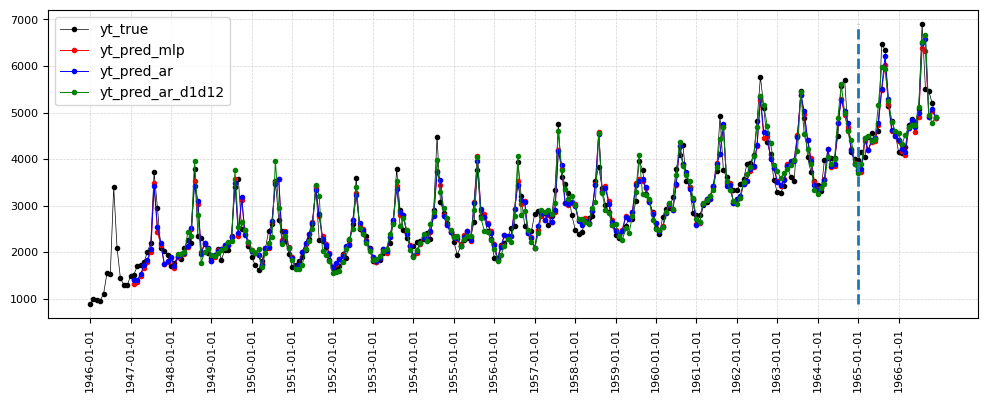

In [4]:
# Top 3 models (plot_time_series supports up to 6 forecast series)
top3 = metrics.set_index("Metrics").T["MSE Test"].nsmallest(3).index.tolist()
plot_time_series(forecasts[["yt_true"] + top3])